# 02 — Data Analysis Report (Deliverable B)

14 numbered tasks. Each cell prints a table/number, draws a chart where useful,
and prints a one- or two-sentence interpretation computed directly from the
data (not hardcoded), so the numbers always match whatever master_train.csv
actually contains.

In [1]:
import sys, os
sys.path.append(os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from features import attach_price

PROCESSED = os.path.join('..', 'data', 'processed')
ASSETS = os.path.join('..', 'app', 'assets')

master_train = pd.read_csv(os.path.join(PROCESSED, 'master_train.csv'))
price_clean = pd.read_csv(os.path.join(ASSETS, 'price_clean.csv'))
weather_clean = pd.read_csv(os.path.join(ASSETS, 'weather_clean.csv'))

print(master_train.shape, price_clean.shape, weather_clean.shape)

(15090, 22) (100, 4) (226, 6)


## B1.1 — Revenue per hectare by crop

crop_type
teff       152301.045731
wheat      135499.515857
maize      114336.383594
barley     109463.805606
sorghum     83622.868662
Name: revenue_birr_per_ha, dtype: float64


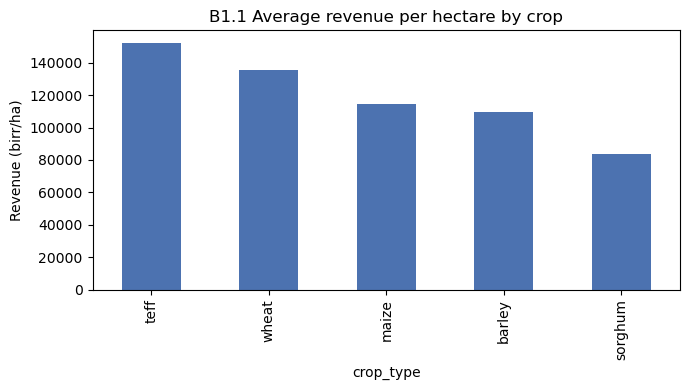

teff has the highest average revenue per hectare at 152301 birr/ha, about 1.8x the lowest-revenue crop (sorghum).


In [2]:
revenue_df = attach_price(master_train, price_clean)
b1_1 = revenue_df.groupby('crop_type')['revenue_birr_per_ha'].mean().sort_values(ascending=False)
print(b1_1)

fig, ax = plt.subplots(figsize=(7, 4))
b1_1.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('Revenue (birr/ha)')
ax.set_title('B1.1 Average revenue per hectare by crop')
plt.tight_layout()
plt.show()

print(f"{b1_1.idxmax()} has the highest average revenue per hectare at {b1_1.max():.0f} birr/ha, "
      f"about {(b1_1.max() / b1_1.min()):.1f}x the lowest-revenue crop ({b1_1.idxmin()}).")

## B1.2 — Price trend, 2021-2024

crop_type  barley   maize  sorghum    teff   wheat
year                                              
2021       3946.8  2602.2   2688.8  6885.0  4305.0
2022       4189.2  2850.2   3120.8  7398.2  4715.2
2023       4769.6  3036.6   3475.6  8033.0  4783.0
2024       4843.4  3233.2   3492.4  8387.8  5557.4


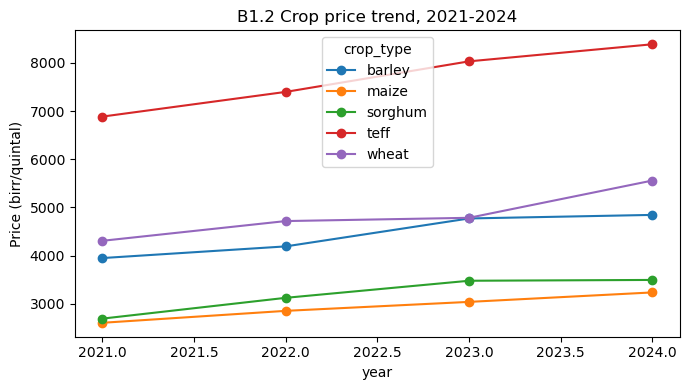

sorghum moved the most from 2021 to 2024: +29.9 percent.


In [3]:
b1_2 = price_clean.groupby(['year', 'crop_type'])['price_birr_per_quintal'].mean().unstack()
print(b1_2)

fig, ax = plt.subplots(figsize=(7, 4))
b1_2.plot(ax=ax, marker='o')
ax.set_ylabel('Price (birr/quintal)')
ax.set_title('B1.2 Crop price trend, 2021-2024')
plt.tight_layout()
plt.show()

change_pct = (b1_2.iloc[-1] - b1_2.iloc[0]) / b1_2.iloc[0] * 100
biggest_mover = change_pct.abs().idxmax()
print(f"{biggest_mover} moved the most from {b1_2.index.min()} to {b1_2.index.max()}: "
      f"{change_pct[biggest_mover]:+.1f} percent.")

## B2.1 — Yield by region

region
tigray    3.131141
amhara    3.128548
oromia    3.073449
snnpr     3.041283
somali    1.464218
Name: yield_tons_per_ha, dtype: float64


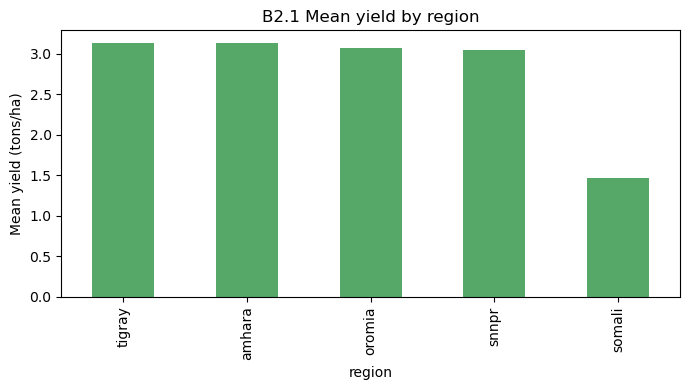

tigray has the highest average yield at 3.13 tons/ha; somali the lowest at 1.46 tons/ha.


In [4]:
b2_1 = master_train.groupby('region')['yield_tons_per_ha'].mean().sort_values(ascending=False)
print(b2_1)

fig, ax = plt.subplots(figsize=(7, 4))
b2_1.plot(kind='bar', ax=ax, color='#55A868')
ax.set_ylabel('Mean yield (tons/ha)')
ax.set_title('B2.1 Mean yield by region')
plt.tight_layout()
plt.show()

print(f"{b2_1.idxmax()} has the highest average yield at {b2_1.max():.2f} tons/ha; "
      f"{b2_1.idxmin()} the lowest at {b2_1.min():.2f} tons/ha.")

## B2.2 — Yield by crop

crop_type
maize      3.904298
wheat      2.801799
sorghum    2.611155
barley     2.466638
teff       2.002736
Name: yield_tons_per_ha, dtype: float64


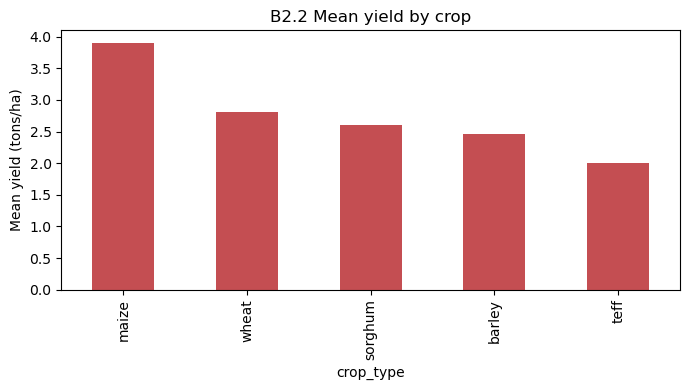

maize yields the most on average (3.90 tons/ha), teff the least (2.00 tons/ha).


In [5]:
b2_2 = master_train.groupby('crop_type')['yield_tons_per_ha'].mean().sort_values(ascending=False)
print(b2_2)

fig, ax = plt.subplots(figsize=(7, 4))
b2_2.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_ylabel('Mean yield (tons/ha)')
ax.set_title('B2.2 Mean yield by crop')
plt.tight_layout()
plt.show()

print(f"{b2_2.idxmax()} yields the most on average ({b2_2.max():.2f} tons/ha), "
      f"{b2_2.idxmin()} the least ({b2_2.min():.2f} tons/ha).")

## B2.3 — Region x crop pivot

In [6]:
b2_3 = master_train.pivot_table(index='region', columns='crop_type', values='yield_tons_per_ha', aggfunc='mean')
print(b2_3.round(2))

best_cell = b2_3.stack().idxmax()
print(f"The single best-performing region-crop combination is {best_cell[1]} in {best_cell[0]}, "
      f"at {b2_3.stack().max():.2f} tons/ha. See fig04_region_crop_heatmap.png for the full picture.")

crop_type  barley  maize  sorghum  teff  wheat
region                                        
amhara       3.19   3.83     2.49  2.48   3.60
oromia       2.68   4.45     2.96  2.29   3.12
snnpr        2.29   4.80     3.11  2.10   2.67
somali       1.12   2.32     1.79  0.83   1.28
tigray       3.01   4.07     2.71  2.33   3.46
The single best-performing region-crop combination is maize in snnpr, at 4.80 tons/ha. See fig04_region_crop_heatmap.png for the full picture.


## B2.4 — Improved seed lift by crop

In [7]:
b2_4 = master_train.groupby(['crop_type', 'improved_seed_used'])['yield_tons_per_ha'].mean().unstack()
b2_4.columns = ['no_improved_seed', 'improved_seed']
b2_4['lift_tons_per_ha'] = b2_4['improved_seed'] - b2_4['no_improved_seed']
b2_4['lift_pct'] = b2_4['lift_tons_per_ha'] / b2_4['no_improved_seed'] * 100
print(b2_4.round(2))

best = b2_4['lift_pct'].idxmax()
print(f"{best} shows the largest improved-seed lift at {b2_4.loc[best, 'lift_pct']:.1f} percent.")

           no_improved_seed  improved_seed  lift_tons_per_ha  lift_pct
crop_type                                                             
barley                 2.31           2.73              0.42     18.30
maize                  3.61           4.39              0.78     21.67
sorghum                2.44           2.89              0.45     18.31
teff                   1.84           2.26              0.42     22.75
wheat                  2.60           3.13              0.54     20.66
teff shows the largest improved-seed lift at 22.7 percent.


## B2.5 — Pest/disease gap by crop

In [8]:
b2_5 = master_train.groupby(['crop_type', 'pest_disease_flag'])['yield_tons_per_ha'].mean().unstack()
b2_5.columns = ['no_pest_disease', 'pest_disease']
b2_5['gap_tons_per_ha'] = b2_5['no_pest_disease'] - b2_5['pest_disease']
print(b2_5.round(2))

worst = b2_5['gap_tons_per_ha'].idxmax()
print(f"{worst} loses the most yield to pest/disease pressure: {b2_5.loc[worst, 'gap_tons_per_ha']:.2f} tons/ha.")

           no_pest_disease  pest_disease  gap_tons_per_ha
crop_type                                                
barley                2.62          1.92             0.70
maize                 4.18          2.97             1.20
sorghum               2.77          2.03             0.74
teff                  2.13          1.57             0.56
wheat                 2.98          2.19             0.78
maize loses the most yield to pest/disease pressure: 1.20 tons/ha.


## B3.1 — Fertilizer response bands

fertilizer_kg_per_ha
(0.497, 17.396]     2.41
(17.396, 29.016]    2.63
(29.016, 38.937]    2.75
(38.937, 57.856]    2.92
(57.856, 136.05]    3.10
Name: yield_tons_per_ha, dtype: float64


C:\Users\abrha\AppData\Local\Temp\ipykernel_28704\2175738270.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  b3_1 = master_train.groupby(fert_band)['yield_tons_per_ha'].mean()


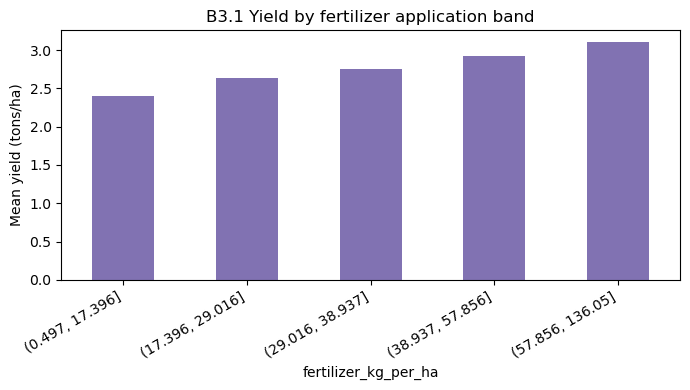

The highest-fertilizer band averages 3.10 tons/ha versus 2.41 tons/ha for the lowest-fertilizer band.


In [9]:
fert_band = pd.qcut(master_train['fertilizer_kg_per_ha'], 5, duplicates='drop')
b3_1 = master_train.groupby(fert_band)['yield_tons_per_ha'].mean()
print(b3_1.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
b3_1.plot(kind='bar', ax=ax, color='#8172B2')
ax.set_ylabel('Mean yield (tons/ha)')
ax.set_title('B3.1 Yield by fertilizer application band')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"The highest-fertilizer band averages {b3_1.iloc[-1]:.2f} tons/ha versus "
      f"{b3_1.iloc[0]:.2f} tons/ha for the lowest-fertilizer band.")

## B3.2 — Altitude bands by crop (flagging small samples)

In [10]:
altitude_band = pd.cut(master_train['altitude_m'], bins=5)
b3_2 = master_train.groupby([altitude_band, 'crop_type'])['yield_tons_per_ha'].agg(['mean', 'count'])
low_n = b3_2[b3_2['count'] < 30]
print(b3_2.round(2))
print()
print(f"{len(low_n)} altitude-band x crop cells have fewer than 30 plots and should be read cautiously.")

                                mean  count
altitude_m           crop_type             
(52.76, 664.643]     barley     2.87     10
                     maize      2.11     60
                     sorghum    1.57    123
                     teff       2.50     14
                     wheat      3.14     11
(664.643, 1273.482]  barley      NaN      0
                     maize      3.79   1108
                     sorghum    2.69   1303
                     teff       0.48     31
                     wheat      0.10      1
(1273.482, 1882.321] barley     0.48     25
                     maize      4.24   1652
                     sorghum    2.73   1434
                     teff       1.68    801
                     wheat      0.60     66
(1882.321, 2491.161] barley     2.03    816
                     maize      2.64    234
                     sorghum    1.64    144
                     teff       2.32   1772
                     wheat      2.61   1122
(2491.161, 3100.0]   barley     

C:\Users\abrha\AppData\Local\Temp\ipykernel_28704\507848914.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  b3_2 = master_train.groupby([altitude_band, 'crop_type'])['yield_tons_per_ha'].agg(['mean', 'count'])


## B3.3 — Planting month effect

In [11]:
b3_3 = master_train.groupby('planting_month')['yield_tons_per_ha'].mean().sort_values(ascending=False)
print(b3_3.round(2))
print(f"Plots sown in {b3_3.idxmax()} average the highest yield ({b3_3.max():.2f} tons/ha); "
      f"note planting_month is strongly tied to crop_type in this dataset, so this reflects crop choice too.")

planting_month
jun    2.81
jul    2.79
aug    2.79
mar    2.73
feb    2.69
Name: yield_tons_per_ha, dtype: float64
Plots sown in jun average the highest yield (2.81 tons/ha); note planting_month is strongly tied to crop_type in this dataset, so this reflects crop choice too.


## B3.4 — Distance-to-market correlation

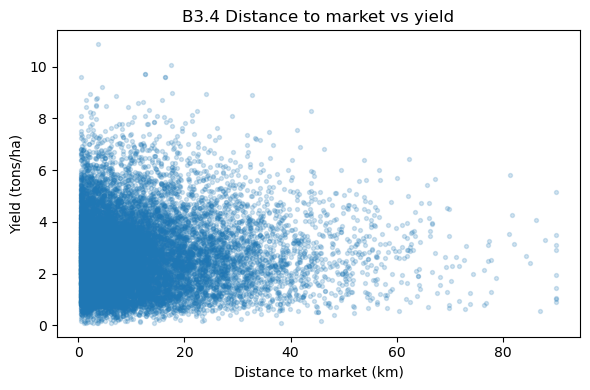

Correlation between distance to market and yield: 0.005 (a weak relationship).


In [12]:
corr_val = master_train['distance_to_market_km'].corr(master_train['yield_tons_per_ha'])

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(master_train['distance_to_market_km'], master_train['yield_tons_per_ha'], alpha=0.2, s=8)
ax.set_xlabel('Distance to market (km)')
ax.set_ylabel('Yield (tons/ha)')
ax.set_title('B3.4 Distance to market vs yield')
plt.tight_layout()
plt.show()

print(f"Correlation between distance to market and yield: {corr_val:.3f} "
      f"({'a weak' if abs(corr_val) < 0.2 else 'a moderate'} relationship).")

## B4.1 — Yield trend by year

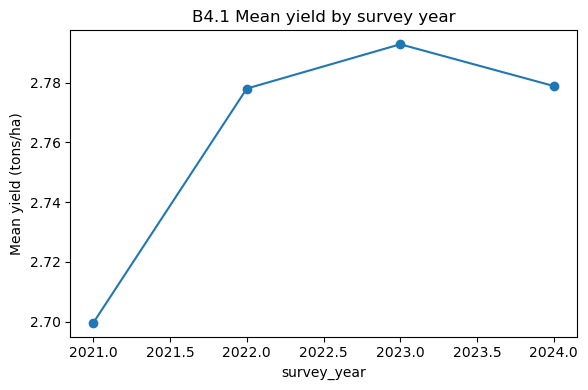

Mean yield has risen from 2.70 tons/ha in 2021 to 2.78 tons/ha in 2024.


In [13]:
b4_1 = master_train.groupby('survey_year')['yield_tons_per_ha'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
b4_1.plot(marker='o', ax=ax)
ax.set_ylabel('Mean yield (tons/ha)')
ax.set_title('B4.1 Mean yield by survey year')
plt.tight_layout()
plt.show()

trend = 'risen' if b4_1.iloc[-1] > b4_1.iloc[0] else 'fallen'
print(f"Mean yield has {trend} from {b4_1.iloc[0]:.2f} tons/ha in {b4_1.index.min()} "
      f"to {b4_1.iloc[-1]:.2f} tons/ha in {b4_1.index.max()}.")

## B4.2 — Weather anomaly by region-year

survey_year  2021  2022  2023  2024
region                             
amhara      -0.35  1.23 -1.58 -0.50
oromia       0.09  0.67 -0.54 -0.94
snnpr        0.94 -0.73 -0.76 -0.65
somali       1.42 -2.81  0.07 -0.01
tigray      -0.46 -1.71 -1.35  2.25


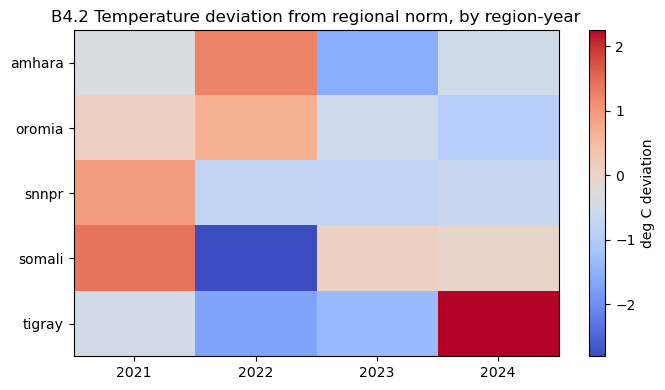

The largest positive temperature anomaly was tigray in 2024, at +2.25 deg C above that region's norm.


In [14]:
b4_2 = master_train.groupby(['region', 'survey_year'])['temp_deviation_from_region_avg'].mean().unstack()
print(b4_2.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(b4_2.values, cmap='coolwarm', aspect='auto')
ax.set_xticks(range(len(b4_2.columns)))
ax.set_xticklabels(b4_2.columns)
ax.set_yticks(range(len(b4_2.index)))
ax.set_yticklabels(b4_2.index)
ax.set_title('B4.2 Temperature deviation from regional norm, by region-year')
plt.colorbar(im, ax=ax, label='deg C deviation')
plt.tight_layout()
plt.show()

hottest = b4_2.stack().idxmax()
print(f"The largest positive temperature anomaly was {hottest[0]} in {hottest[1]}, "
      f"at {b4_2.stack().max():+.2f} deg C above that region's norm.")

## B4.3 — Plot-reported vs station-derived rainfall agreement

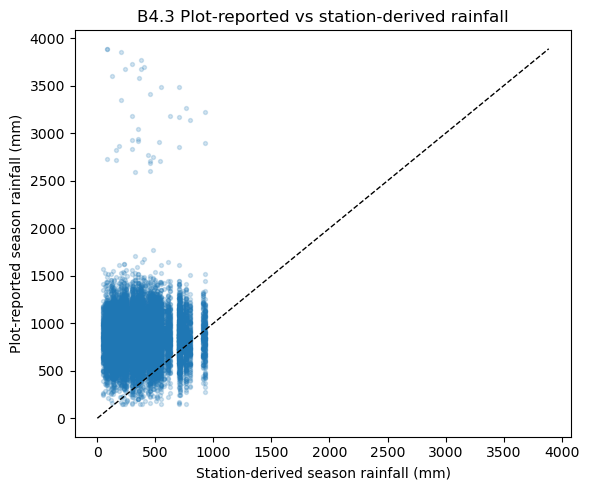

Correlation between the plot's self-reported season rainfall and the station-derived season rainfall: 0.006. A value well below 1.0 suggests the two sources disagree meaningfully, which is itself worth flagging in the report.


In [15]:
rain_corr = master_train['rainfall_mm_season'].corr(master_train['season_rainfall_mm_total'])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(master_train['season_rainfall_mm_total'], master_train['rainfall_mm_season'], alpha=0.2, s=8)
lims = [0, max(master_train['season_rainfall_mm_total'].max(), master_train['rainfall_mm_season'].max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Station-derived season rainfall (mm)')
ax.set_ylabel('Plot-reported season rainfall (mm)')
ax.set_title('B4.3 Plot-reported vs station-derived rainfall')
plt.tight_layout()
plt.show()

print(f"Correlation between the plot's self-reported season rainfall and the station-derived "
      f"season rainfall: {rain_corr:.3f}. A value well below 1.0 suggests the two sources disagree "
      f"meaningfully, which is itself worth flagging in the report.")